# 08 — IMDB 通用向量分类：真实留出测试 + general-vector QOS 数组仿真

这个 notebook 回答一个比“重画原论文 Fig. 2”更直接的问题：

> 用官方 IMDB 的 25,000 条训练评论学到一个真实分类权重后，固定提交中的 general-vector quantum oracle sketching（QOS）能把这个权重方向恢复到什么程度？恢复后的方向还能保留多少测试集分类准确率？

实验固定参考仓库提交：

- 仓库：[haimengzhao/quantum-oracle-sketching](https://github.com/haimengzhao/quantum-oracle-sketching)
- 提交：[`10c092cefcfdff9951bf5729bd2ffb4c25fe2254`](https://github.com/haimengzhao/quantum-oracle-sketching/tree/10c092cefcfdff9951bf5729bd2ffb4c25fe2254)
- expected general-vector 路径：[`qos.py::q_state_sketch`](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/qos.py)
- active sampled 路径：[`qos_sampling.py::q_state_sketch`](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/qos_sampling.py)
- QSVT 相位与乘法顺序：[`qsvt.py`](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/qsvt.py)

## 先划清三类结论

| 层次 | 本 notebook 做了什么 | 可以怎样表述 |
|---|---|---|
| **A. 实测经典分类** | 在官方 25k train 上训练 Ridge，在从未参与训练的官方 25k test 上测准确率 | “真实留出测试准确率” |
| **B. 实测 QOS 数组仿真** | 用 NumPy 保持固定提交的 expected/active 数值核心不变，并通过尺度安全的单位向量 wrapper 重建学到的权重方向，再重新计算 test 准确率、保真度和成功概率 | “固定 source core + 单位向量 wrapper 的数组级仿真结果” |
| **C. 理论资源公式** | 把训练矩阵统计量代入原仓库 IMDB 脚本中的逻辑量子比特公式 | “公式估算的逻辑量子比特”，不是实际占用 |

这里**没有**运行量子硬件、没有测量真实量子线路，也没有实现物理量子态层析。将经典测试矩阵乘以仿真得到的数组，是离线验证方法，不是“量子读出”。

> **科学修订说明：** 主曲线不会把原始 Ridge 权重 $w$ 直接送入 active source core。固定源码会先把采样值除以 $\lVert w\rVert_2$，随后又令 $t=D/(3\lVert w\rVert_2)$；对非单位输入会出现二次范数缩放。主实验因此先构造 $u=w/\lVert w\rVert_2$，使 core 内部 `norm=1`。原始直送路径只保留为单独的尺度审计，不作为主结果。

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/qos-imdb-mpl-cache")

import hashlib
import json
import math
import platform
import shutil
import tarfile
import time
import urllib.request
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import nbformat
import numpy as np
import pandas as pd
import scipy
from IPython.display import Markdown, display
from scipy.linalg import hadamard
from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score

NOTEBOOK_T0 = time.perf_counter()
SEED = 20260729
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")


def find_stage_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, start / "Quafu_stage", *start.parents]
    for candidate in candidates:
        if candidate.name == "Quafu_stage" and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("找不到 Quafu_stage；请从项目目录或 Quafu_stage 目录运行。")


STAGE_ROOT = find_stage_root(Path.cwd())
RESULTS_DIR = STAGE_ROOT / "results"
FIGURE_DIR = STAGE_ROOT / "assets" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ENVIRONMENT = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "scikit_learn": sklearn_version,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "nbformat": nbformat.__version__,
}

print("Quafu_stage:", STAGE_ROOT)
print("随机种子:", SEED)
display(pd.DataFrame([ENVIRONMENT]))

Quafu_stage: /Users/tangzhi/.codex/.chatgpt-projects/g-p-6a5f771ad30c8191a3fc5b9cc6ea6d75/Quafu_stage
随机种子: 20260729


,python,numpy,scipy,scikit_learn,pandas,matplotlib,nbformat
0,3.13.7,2.3.3,1.16.1,1.9.0,2.3.2,3.10.6,5.10.4


## 1. 数据：只使用官方 train/test，默认完全离线

读取顺序如下：

1. 环境变量 `IMDB_DATA_ROOT`；
2. 已准备好的 `/private/tmp/qos-imdb-data/aclImdb`；
3. 若前两者都不存在，才进入下载助手。

`DOWNLOAD_IF_MISSING=False` 是刻意的默认值，所以正常重跑不会访问网络。需要首次下载时，手动把它改成 `True`；助手会从 Stanford 官方 URL 下载、核对 SHA-256、检查 tar 路径穿越后再解压。

训练与测试严格分开：

- `HashingVectorizer` 是无词表、无 `fit` 状态的确定性变换；
- Ridge 只调用 `fit(X_train, y_train)`；
- test 只用于最终评估；
- `train/unsup` 不会进入任何一步。

官方归档的已知校验值来自 TensorFlow Datasets 的 checksum registry；本实验的 manifest 也会保存 URL 和 SHA-256。

In [2]:
IMDB_ARCHIVE_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
IMDB_ARCHIVE_SHA256 = "c40f74a18d3b61f90feba1e17730e0d38e8b97c05fde7008942e91923d1658fe"
IMDB_ARCHIVE_BYTES = 84_125_825
DOWNLOAD_IF_MISSING = False


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def safe_extract_tar(archive: Path, destination: Path) -> None:
    destination = destination.resolve()
    with tarfile.open(archive, "r:gz") as tar:
        for member in tar.getmembers():
            target = (destination / member.name).resolve()
            if target != destination and destination not in target.parents:
                raise RuntimeError(f"检测到不安全的归档路径: {member.name}")
        tar.extractall(destination)


def download_official_imdb(destination_root: Path, enabled: bool = False) -> Path:
    # 显式开启后才下载；下载后做 SHA-256 与安全解压检查。
    if not enabled:
        raise FileNotFoundError(
            "本地没有 IMDB 数据，且 DOWNLOAD_IF_MISSING=False。"
            "请设置 IMDB_DATA_ROOT，或明确把 DOWNLOAD_IF_MISSING 改为 True。"
        )
    destination_root.mkdir(parents=True, exist_ok=True)
    archive = destination_root / "aclImdb_v1.tar.gz"
    extracted = destination_root / "aclImdb"
    if not archive.exists():
        print("正在从 Stanford 官方地址下载:", IMDB_ARCHIVE_URL)
        urllib.request.urlretrieve(IMDB_ARCHIVE_URL, archive)
    observed_sha = sha256_file(archive)
    if observed_sha != IMDB_ARCHIVE_SHA256:
        raise RuntimeError(
            f"IMDB 归档 SHA-256 不匹配：{observed_sha} != {IMDB_ARCHIVE_SHA256}"
        )
    if not extracted.is_dir():
        safe_extract_tar(archive, destination_root)
    return extracted


def normalize_imdb_root(candidate: Path) -> Path | None:
    candidate = candidate.expanduser().resolve()
    if candidate.name == "aclImdb" and candidate.is_dir():
        return candidate
    nested = candidate / "aclImdb"
    if nested.is_dir():
        return nested
    return None


def resolve_imdb_root() -> tuple[Path, str]:
    env_value = os.environ.get("IMDB_DATA_ROOT")
    if env_value:
        resolved = normalize_imdb_root(Path(env_value))
        if resolved is not None:
            return resolved, "IMDB_DATA_ROOT"
        print("警告：IMDB_DATA_ROOT 不存在或不含 aclImdb，继续检查离线回退路径。")

    fallback = normalize_imdb_root(Path("/private/tmp/qos-imdb-data/aclImdb"))
    if fallback is not None:
        return fallback, "offline_fallback"

    download_root = STAGE_ROOT / "data" / "cache" / "imdb"
    return download_official_imdb(download_root, enabled=DOWNLOAD_IF_MISSING), "download_helper"


IMDB_ROOT, IMDB_ROOT_SOURCE = resolve_imdb_root()
print("IMDB 数据目录:", IMDB_ROOT)
print("解析来源:", IMDB_ROOT_SOURCE)
print("默认联网下载:", DOWNLOAD_IF_MISSING)

IMDB 数据目录: /private/tmp/qos-imdb-data/aclImdb
解析来源: offline_fallback
默认联网下载: False


In [3]:
load_t0 = time.perf_counter()
train_bundle = load_files(
    IMDB_ROOT / "train",
    categories=["neg", "pos"],
    encoding="utf-8",
    decode_error="replace",
    shuffle=False,
)
test_bundle = load_files(
    IMDB_ROOT / "test",
    categories=["neg", "pos"],
    encoding="utf-8",
    decode_error="replace",
    shuffle=False,
)

assert train_bundle.target_names == ["neg", "pos"]
assert test_bundle.target_names == ["neg", "pos"]
assert len(train_bundle.data) == 25_000
assert len(test_bundle.data) == 25_000
assert np.array_equal(np.bincount(train_bundle.target), [12_500, 12_500])
assert np.array_equal(np.bincount(test_bundle.target), [12_500, 12_500])
assert set(map(str, train_bundle.filenames)).isdisjoint(set(map(str, test_bundle.filenames)))

positive_index = train_bundle.target_names.index("pos")
y_train = np.where(train_bundle.target == positive_index, 1, -1).astype(np.int8)
y_test = np.where(test_bundle.target == positive_index, 1, -1).astype(np.int8)
train_texts = train_bundle.data
test_texts = test_bundle.data
data_load_seconds = time.perf_counter() - load_t0

split_df = pd.DataFrame(
    [
        {
            "split": "official_train",
            "n_reviews": len(train_texts),
            "negative": int(np.sum(y_train == -1)),
            "positive": int(np.sum(y_train == 1)),
            "used_for_fit": True,
        },
        {
            "split": "official_test",
            "n_reviews": len(test_texts),
            "negative": int(np.sum(y_test == -1)),
            "positive": int(np.sum(y_test == 1)),
            "used_for_fit": False,
        },
    ]
)

dataset_manifest = {
    "dataset": "Large Movie Review Dataset (aclImdb v1)",
    "archive_url": IMDB_ARCHIVE_URL,
    "archive_sha256": IMDB_ARCHIVE_SHA256,
    "archive_expected_bytes": IMDB_ARCHIVE_BYTES,
    "archive_sha256_source": (
        "TensorFlow Datasets imdb_reviews/checksums.tsv; helper verifies it if downloading"
    ),
    "resolved_data_root": str(IMDB_ROOT),
    "resolved_by": IMDB_ROOT_SOURCE,
    "download_if_missing": DOWNLOAD_IF_MISSING,
    "categories": ["neg", "pos"],
    "excluded_directory": "train/unsup",
    "official_train_count": len(train_texts),
    "official_test_count": len(test_texts),
    "official_train_balance": {"neg": int(np.sum(y_train == -1)), "pos": int(np.sum(y_train == 1))},
    "official_test_balance": {"neg": int(np.sum(y_test == -1)), "pos": int(np.sum(y_test == 1))},
    "train_test_file_paths_disjoint": True,
    "load_seconds": data_load_seconds,
}
manifest_path = RESULTS_DIR / "imdb_dataset_manifest.json"
manifest_path.write_text(
    json.dumps(dataset_manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)

display(split_df)
print(f"数据加载耗时: {data_load_seconds:.3f} s")
print("manifest:", manifest_path.relative_to(STAGE_ROOT))

,split,n_reviews,negative,positive,used_for_fit
0,official_train,25000,12500,12500,True
1,official_test,25000,12500,12500,False


数据加载耗时: 3.049 s
manifest: results/imdb_dataset_manifest.json


## 2. 实测经典分类：HashingVectorizer + Ridge

文本被映射到 $D$ 维、逐行 $L_2$ 归一化的稀疏向量。模型为

$$
\widehat{y}(x)=\operatorname{sign}(w^\top x+b).
$$

这里保留截距 $b$。选 `RidgeClassifier(alpha=10, solver="lsqr")` 是为了让所有维度使用同一、适合 CPU 稀疏矩阵的设置，而不是在 test 上调参。

维度网格为

$$
D\in\{128,256,512,1024,2048,4096,8192,16384\}.
$$

general-vector QOS 选择 $D=256$：它足以得到非平凡的真实留出准确率，同时 $256\times256$ Walsh–Hadamard 数组可以快速做多预算、多重复的完整仿真。更高维分类结果仍会全部真实训练并保存。

In [4]:
DIMENSIONS = [128, 256, 512, 1024, 2048, 4096, 8192, 16384]
QOS_DIMENSION = 256
RIDGE_ALPHA = 10.0

classification_rows = []
selected = {}

for dimension in DIMENSIONS:
    vectorizer = HashingVectorizer(
        n_features=dimension,
        alternate_sign=True,
        norm="l2",
        stop_words="english",
        ngram_range=(1, 2),
        strip_accents="unicode",
        lowercase=True,
        dtype=np.float64,
    )

    vectorize_t0 = time.perf_counter()
    X_train = vectorizer.transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    vectorize_seconds = time.perf_counter() - vectorize_t0

    fit_t0 = time.perf_counter()
    classifier = RidgeClassifier(
        alpha=RIDGE_ALPHA,
        solver="lsqr",
        fit_intercept=True,
        tol=1e-4,
    )
    classifier.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - fit_t0

    eval_t0 = time.perf_counter()
    train_accuracy = accuracy_score(y_train, classifier.predict(X_train))
    test_accuracy = accuracy_score(y_test, classifier.predict(X_test))
    evaluate_seconds = time.perf_counter() - eval_t0

    max_row_sparsity = int(X_train.getnnz(axis=1).max())
    max_col_sparsity = int(X_train.getnnz(axis=0).max())
    sparsity = max(max_row_sparsity, max_col_sparsity)
    logical_qubits_formula = int(
        2 * math.ceil(math.log2(X_train.shape[0] + 2 * dimension))
        + math.ceil(math.log2(sparsity + 1))
        + 4
    )
    weight = np.asarray(classifier.coef_, dtype=np.float64).reshape(-1)
    intercept = float(np.asarray(classifier.intercept_).reshape(-1)[0])

    classification_rows.append(
        {
            "dimension": dimension,
            "official_train_accuracy": train_accuracy,
            "official_test_accuracy": test_accuracy,
            "ridge_alpha": RIDGE_ALPHA,
            "intercept": intercept,
            "weight_l2_norm": float(np.linalg.norm(weight)),
            "train_nnz": int(X_train.nnz),
            "test_nnz": int(X_test.nnz),
            "max_row_sparsity_train": max_row_sparsity,
            "max_col_sparsity_train": max_col_sparsity,
            "sparsity_formula_input": sparsity,
            "sparsity_definition": "max(max_row_sparsity_train, max_col_sparsity_train)",
            "theory_logical_qubits_formula": logical_qubits_formula,
            "machine_size_streaming_D": dimension,
            "machine_size_sparse_train_nnz": int(X_train.nnz),
            "machine_size_qos_logical_qubits_formula": logical_qubits_formula,
            "machine_size_accuracy_shared_metric": test_accuracy,
            "vectorize_seconds": vectorize_seconds,
            "fit_seconds": fit_seconds,
            "evaluate_seconds": evaluate_seconds,
        }
    )

    print(
        f"D={dimension:5d} | test={test_accuracy:.4f} | "
        f"formula qubits={logical_qubits_formula:2d} | "
        f"time={vectorize_seconds + fit_seconds + evaluate_seconds:.2f}s"
    )

    if dimension == QOS_DIMENSION:
        selected = {
            "X_train": X_train,
            "X_test": X_test,
            "classifier": classifier,
            "weight": weight,
            "intercept": intercept,
            "vectorizer": vectorizer,
        }

classification_df = pd.DataFrame(classification_rows)
classification_csv = RESULTS_DIR / "imdb_hashing_ridge_accuracy.csv"
classification_df.to_csv(classification_csv, index=False)

assert selected["X_train"].shape == (25_000, QOS_DIMENSION)
assert selected["X_test"].shape == (25_000, QOS_DIMENSION)

display(
    classification_df[
        [
            "dimension",
            "official_train_accuracy",
            "official_test_accuracy",
            "intercept",
            "weight_l2_norm",
            "theory_logical_qubits_formula",
        ]
    ].style.format(
        {
            "official_train_accuracy": "{:.4f}",
            "official_test_accuracy": "{:.4f}",
            "intercept": "{:.5f}",
            "weight_l2_norm": "{:.4f}",
        }
    )
)
print("CSV:", classification_csv.relative_to(STAGE_ROOT))

D=  128 | test=0.6364 | formula qubits=49 | time=3.43s


D=  256 | test=0.6774 | formula qubits=49 | time=3.49s


D=  512 | test=0.7263 | formula qubits=49 | time=3.46s


D= 1024 | test=0.7613 | formula qubits=49 | time=3.45s


D= 2048 | test=0.7930 | formula qubits=48 | time=3.48s


D= 4096 | test=0.8200 | formula qubits=50 | time=3.52s


D= 8192 | test=0.8386 | formula qubits=50 | time=3.51s


D=16384 | test=0.8520 | formula qubits=50 | time=3.53s


,dimension,official_train_accuracy,official_test_accuracy,intercept,weight_l2_norm,theory_logical_qubits_formula
0,128,0.6464,0.6364,0.08563,3.5701,49
1,256,0.6952,0.6774,0.03129,5.7267,49
2,512,0.7418,0.7263,0.05809,8.3437,49
3,1024,0.7832,0.7613,0.06188,10.9103,49
4,2048,0.8264,0.7930,0.04257,13.2890,48
5,4096,0.8579,0.8200,0.02769,15.0239,50
6,8192,0.8799,0.8386,0.02845,16.1607,50
7,16384,0.8907,0.8520,0.03396,16.7808,50


CSV: results/imdb_hashing_ridge_accuracy.csv


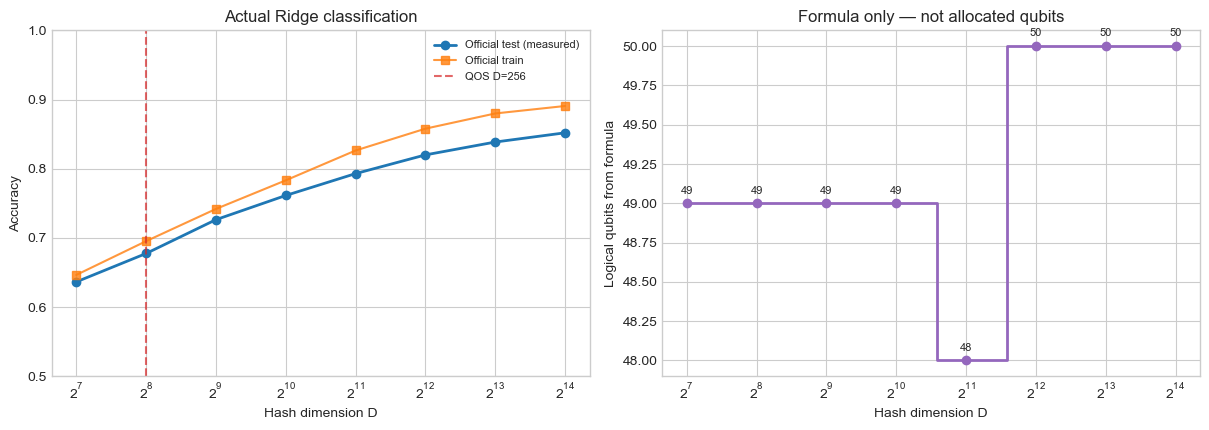

图: assets/figures/imdb_hashing_accuracy_and_formula.png


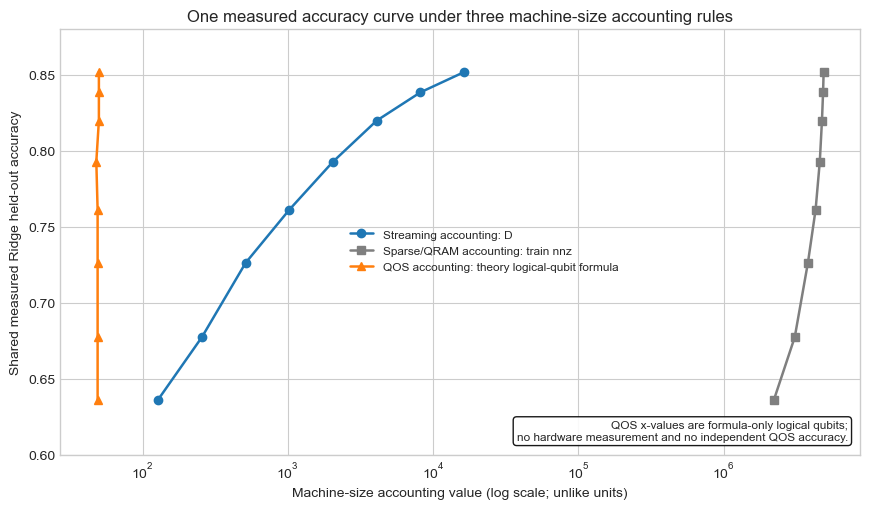

记账对照图: assets/figures/imdb_accuracy_vs_machine_size_accounting.png


In [5]:
classification_figure = FIGURE_DIR / "imdb_hashing_accuracy_and_formula.png"

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4))

axes[0].plot(
    classification_df["dimension"],
    classification_df["official_test_accuracy"],
    marker="o",
    linewidth=2,
    label="Official test (measured)",
)
axes[0].plot(
    classification_df["dimension"],
    classification_df["official_train_accuracy"],
    marker="s",
    linewidth=1.5,
    alpha=0.8,
    label="Official train",
)
axes[0].axvline(QOS_DIMENSION, color="tab:red", linestyle="--", alpha=0.7, label="QOS D=256")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("Hash dimension D")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title("Actual Ridge classification")
axes[0].legend(fontsize=8)

axes[1].step(
    classification_df["dimension"],
    classification_df["theory_logical_qubits_formula"],
    where="mid",
    marker="o",
    linewidth=2,
    color="tab:purple",
)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Hash dimension D")
axes[1].set_ylabel("Logical qubits from formula")
axes[1].set_title("Formula only — not allocated qubits")
for _, row in classification_df.iterrows():
    axes[1].annotate(
        str(int(row["theory_logical_qubits_formula"])),
        (row["dimension"], row["theory_logical_qubits_formula"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )

fig.tight_layout()
fig.savefig(classification_figure, dpi=180, bbox_inches="tight")
plt.show()
print("图:", classification_figure.relative_to(STAGE_ROOT))

# 同一个 measured held-out accuracy，对照三种不同的 machine-size 记账规则。
# 这不是三种算法各自独立得到的 accuracy。
machine_size_accounting_figure = (
    FIGURE_DIR / "imdb_accuracy_vs_machine_size_accounting.png"
)
fig, ax = plt.subplots(figsize=(8.8, 5.2))
accounting_series = [
    (
        "machine_size_streaming_D",
        "Streaming accounting: D",
        "o",
        "tab:blue",
    ),
    (
        "machine_size_sparse_train_nnz",
        "Sparse/QRAM accounting: train nnz",
        "s",
        "tab:gray",
    ),
    (
        "machine_size_qos_logical_qubits_formula",
        "QOS accounting: theory logical-qubit formula",
        "^",
        "tab:orange",
    ),
]
for column, label, marker, color in accounting_series:
    ax.plot(
        classification_df[column],
        classification_df["machine_size_accuracy_shared_metric"],
        marker=marker,
        linewidth=1.8,
        markersize=6,
        color=color,
        label=label,
    )

ax.set_xscale("log")
ax.set_xlabel("Machine-size accounting value (log scale; unlike units)")
ax.set_ylabel("Shared measured Ridge held-out accuracy")
ax.set_ylim(0.60, 0.88)
ax.set_title(
    "One measured accuracy curve under three machine-size accounting rules"
)
ax.text(
    0.985,
    0.03,
    "QOS x-values are formula-only logical qubits;\n"
    "no hardware measurement and no independent QOS accuracy.",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
ax.legend(fontsize=8.5, loc="center", bbox_to_anchor=(0.53, 0.48))
fig.tight_layout()
fig.savefig(machine_size_accounting_figure, dpi=180, bbox_inches="tight")
plt.show()
print("记账对照图:", machine_size_accounting_figure.relative_to(STAGE_ROOT))

### 2.1 同一准确率下的三种 machine-size 记账

新增的 `accuracy vs machine-size accounting` 图**不是**三种算法各自独立测得的准确率对比。每个 $D$ 只有一个真实 measured held-out Ridge accuracy，纵轴完全相同；横轴分别换成：

$$
S_{\mathrm{streaming}}=D,
\qquad
S_{\mathrm{sparse/QRAM}}=\operatorname{nnz}(X_{\mathrm{train}}),
\qquad
S_{\mathrm{QOS}}=Q_{\mathrm{logical}}\text{（理论公式）}.
$$

这张图只帮助直观看见资源记账尺度的分离。三种横轴单位并不相同，QOS 也不是硬件测量；对应 CSV 字段带有 `machine_size_*` 前缀。

## 3. general-vector QOS 的核心机制、尺度安全 wrapper 与样本账本

### 3.1 目标方向与分类尺度

Ridge 学到 $w\in\mathbb{R}^{D}$ 和截距 $b$。量子态编码的目标只应依赖方向：

$$
u=\frac{w}{\lVert w\rVert_2},
\qquad
|u\rangle=\sum_{j=0}^{D-1}u_j|j\rangle.
$$

本 notebook 的**主实验输入是单位向量 $u$，不是原始 $w$**。设 source core 返回未归一化数组 $q$，离线评估步骤为

$$
p_{\mathrm{succ}}=\lVert q\rVert_2^2,\qquad
\widetilde q=\frac{q}{\lVert q\rVert_2},\qquad
\widetilde w=\lVert w\rVert_2\,\widetilde q,
$$

再计算

$$
\widehat y_{\mathrm{QOS}}(x)
=\operatorname{sign}\!\left(x^\top\widetilde w+b\right).
$$

乘回 $\lVert w\rVert_2$、保留 $b$、以及用经典测试矩阵评分，都是**经典离线验证**，不是从量子设备读出完整系数。

### 3.2 为什么必须先做单位向量 wrapper？

固定提交的 active core 对输入向量 $v$ 依次执行：

$$
v_j\longmapsto\frac{v_j}{\lVert v\rVert_2},
\qquad
t_{\mathrm{active}}=\frac{D}{3\lVert v\rVert_2}.
$$

所以相位贡献整体正比于

$$
\frac{v_j}{\lVert v\rVert_2^2}.
$$

若直接把 $v$ 缩放为 $cv$，贡献会多出 $1/c$；这不符合“量子态只编码方向”的尺度不变性。这里采用 **intended scale-safe unit-vector wrapper**：

1. 在 core 外计算 $u=w/\lVert w\rVert_2$；
2. 把 $u$ 送入完全未改动的 source core，此时 core 看到 $\lVert u\rVert_2=1$；
3. 条件态归一化后，仅在经典下游评分时乘回 $\lVert w\rVert_2$ 并加 $b$。

expected 路径也接收同一个 $u$，形成统一输入契约。随后会单独运行 `raw_source_scale_audit`，展示原始 active core 直接接收 $w$ 或 $cw$ 时的差异；该审计不是主曲线。

### 3.3 随机符号、Hadamard 域与 QSVT

两条路径都先固定随机符号 $h_j\in\{-1,+1\}$，在 Walsh–Hadamard 域编码带符号的单位方向；相位经过 LCU 变成正弦块编码，再用 QSVT 多项式近似 $\arcsin$，最后逆 Hadamard 并撤销随机符号。

单位输入使主实验中的固定常数变为

$$
t_{\mathrm{expected}}=\frac{D}{5},
\qquad
t_{\mathrm{active}}=\frac{D}{3}.
$$

### 3.4 `degree=4` 为什么只消费三组？

固定提交用 degree 4 做 Chebyshev 拟合，但目标是奇函数，偶次系数在数值上接近 0；`sym_qsp` 最终返回 **4 个相位**，因此 QSVT 需要 $4-1=3$ 个块编码。

| 路径 | 每组大小 | 生成/记账 | 真正传入 QSVT | 未使用 |
|---|---:|---:|---:|---:|
| expected | $m$ | 返回值记为 $3m$ 次 query-sample calls | 同一个 expected block 被调用 3 次 | $0$ |
| active sampled | $m$ | 主动抽取 $4m$ 对 $(j,u_j)$ 并切成 4 组 | 只传入前 3 组，即 $3m$ 对 | 第 4 组的 $m$ 对 |

active 利用率为 $3/4=75\%$。主图横轴采用双方都被 QSVT 消费的 $3m$；CSV/JSON 另外保存 active 实际抽取的 $4m$。

In [6]:
QSVT_DEGREE_REQUEST = 4
QSVT_CHEB_COEFFICIENTS = np.array(
    [
        8.5063411018431346e-17,
        0.76232595836030714,
        1.8509883381644016e-16,
        0.047758374027225471,
        2.1561842386420601e-16,
    ],
    dtype=np.float64,
)
QSVT_ANGLES = np.array(
    [
        0.81466602029631641,
        2.0136764378313528,
        2.0136764378313528,
        0.81466602029631641,
    ],
    dtype=np.float64,
)
QSVT_BLOCK_CALLS = len(QSVT_ANGLES) - 1


def apply_qsvt_imperfect_diag_numpy(
    block_sequence: np.ndarray, angle_set: np.ndarray = QSVT_ANGLES
) -> np.ndarray:
    # NumPy 等价实现 qsvt.py::apply_qsvt_imperfect_diag 的 1-ancilla 分支。
    block_sequence = np.asarray(block_sequence, dtype=np.complex128)
    if block_sequence.ndim != 4 or block_sequence.shape[1:3] != (2, 2):
        raise ValueError("block_sequence 必须是 (num_gates, 2, 2, dim)")
    if block_sequence.shape[0] != len(angle_set) - 1:
        raise ValueError("块编码数必须等于 QSVT 相位数减一")

    dimension = block_sequence.shape[-1]
    phase_pattern = np.array([1.0, -1.0])
    initial_phase = np.exp(1j * angle_set[0] * phase_pattern)
    circuit = np.zeros((dimension, 2, 2), dtype=np.complex128)
    circuit[:, 0, 0] = initial_phase[0]
    circuit[:, 1, 1] = initial_phase[1]
    circuit *= np.exp(-1j * np.pi * len(angle_set) / 2)

    for angle, block in zip(angle_set[1:], block_sequence):
        circuit = circuit @ block.transpose(2, 0, 1)
        circuit *= np.exp(1j * angle * phase_pattern)[None, None, :]

    return circuit.transpose(1, 2, 0)


# 独立数值单元测试：QSVT 输出应等于固定的 Chebyshev 多项式。
validation_x = np.linspace(-np.sin(1.0), np.sin(1.0), 401)
validation_cos = np.sqrt(1.0 - validation_x**2)
validation_block = np.stack(
    [validation_x, validation_cos, validation_cos, -validation_x], axis=0
).reshape(2, 2, -1)
validation_sequence = np.repeat(
    validation_block[None, :, :, :], QSVT_BLOCK_CALLS, axis=0
)
validation_qsvt = np.real(
    apply_qsvt_imperfect_diag_numpy(validation_sequence)[0, 0]
)
validation_poly = np.polynomial.chebyshev.chebval(
    validation_x, QSVT_CHEB_COEFFICIENTS
)
qsvt_validation_max_error = float(
    np.max(np.abs(validation_qsvt - validation_poly))
)

assert len(QSVT_ANGLES) == 4
assert QSVT_BLOCK_CALLS == 3
assert qsvt_validation_max_error < 1e-12

display(
    pd.DataFrame(
        {
            "quantity": [
                "degree request",
                "angle count",
                "block calls",
                "QSVT-vs-Chebyshev max error",
            ],
            "value": [
                QSVT_DEGREE_REQUEST,
                len(QSVT_ANGLES),
                QSVT_BLOCK_CALLS,
                qsvt_validation_max_error,
            ],
        }
    )
)
print("固定相位（radian）:", QSVT_ANGLES)

,quantity,value
0,degree request,4.000000e+00
1,angle count,4.000000e+00
2,block calls,3.000000e+00
3,QSVT-vs-Chebyshev max error,6.106227e-16


固定相位（radian）: [0.814666 2.013676 2.013676 0.814666]


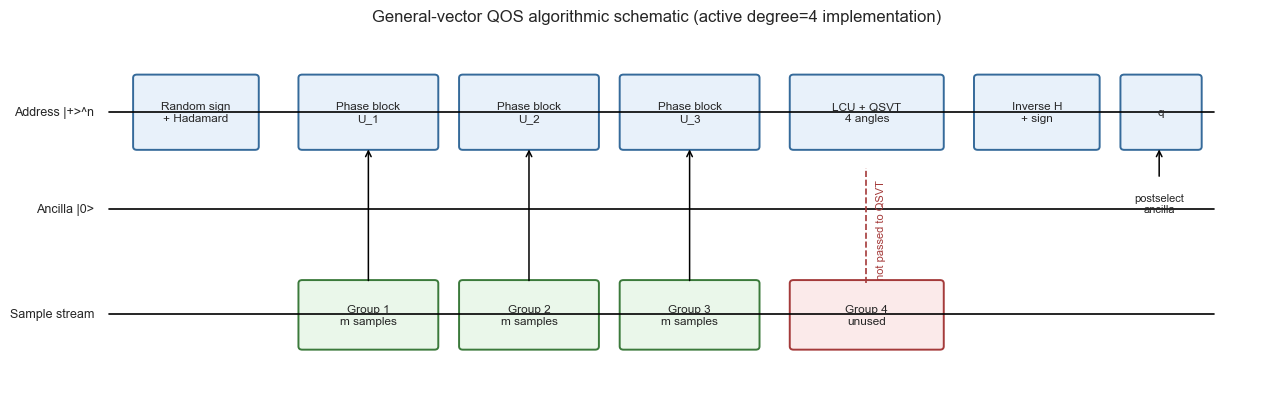

概念示意图: assets/figures/imdb_general_vector_qos_schematic.png


In [7]:
# 算法级线路示意图：不是可提交到硬件的门级 netlist。
schematic_path = FIGURE_DIR / "imdb_general_vector_qos_schematic.png"

fig, ax = plt.subplots(figsize=(13.0, 4.2))
ax.set_xlim(0, 13)
ax.set_ylim(-0.3, 4.2)
ax.axis("off")

wire_y = {"Address |+>^n": 3.25, "Ancilla |0>": 2.05, "Sample stream": 0.75}
for label, y in wire_y.items():
    ax.plot([0.7, 12.4], [y, y], color="black", linewidth=1.2)
    ax.text(0.55, y, label, ha="right", va="center", fontsize=9)


def add_box(x, y, width, height, text, facecolor="#E8F1FA", edgecolor="#356A9A"):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.04",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=1.4,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=8.5)


add_box(1.0, 2.82, 1.25, 0.85, "Random sign\n+ Hadamard")
add_box(2.75, 2.82, 1.4, 0.85, "Phase block\nU_1")
add_box(4.45, 2.82, 1.4, 0.85, "Phase block\nU_2")
add_box(6.15, 2.82, 1.4, 0.85, "Phase block\nU_3")
add_box(7.95, 2.82, 1.55, 0.85, "LCU + QSVT\n4 angles")
add_box(9.9, 2.82, 1.25, 0.85, "Inverse H\n+ sign")
add_box(11.45, 2.82, 0.78, 0.85, "q")

add_box(2.75, 0.35, 1.4, 0.78, "Group 1\nm samples", "#EAF7EA", "#3B7A3B")
add_box(4.45, 0.35, 1.4, 0.78, "Group 2\nm samples", "#EAF7EA", "#3B7A3B")
add_box(6.15, 0.35, 1.4, 0.78, "Group 3\nm samples", "#EAF7EA", "#3B7A3B")
add_box(7.95, 0.35, 1.55, 0.78, "Group 4\nunused", "#FBEAEA", "#A43A3A")

for x in [3.45, 5.15, 6.85]:
    ax.annotate("", xy=(x, 2.82), xytext=(x, 1.13), arrowprops={"arrowstyle": "->", "lw": 1.1})
ax.plot([8.72, 8.72], [1.13, 2.55], color="#A43A3A", linestyle="--", linewidth=1.2)
ax.text(8.82, 1.8, "not passed to QSVT", color="#A43A3A", fontsize=8, rotation=90, va="center")
ax.annotate("", xy=(11.82, 2.82), xytext=(11.82, 2.42), arrowprops={"arrowstyle": "->", "lw": 1.1})
ax.text(11.82, 2.25, "postselect\nancilla", ha="center", va="top", fontsize=8)

ax.set_title(
    "General-vector QOS algorithmic schematic (active degree=4 implementation)",
    fontsize=12,
    pad=10,
)
fig.tight_layout()
fig.savefig(schematic_path, dpi=180, bbox_inches="tight")
plt.show()
print("概念示意图:", schematic_path.relative_to(STAGE_ROOT))

In [8]:
weight = selected["weight"].astype(np.float64, copy=True)
intercept = float(selected["intercept"])
X_test_qos = selected["X_test"]
weight_norm = float(np.linalg.norm(weight))
target_direction = weight / weight_norm
qos_source_direction = target_direction.copy()
dimension = weight.size

assert dimension == QOS_DIMENSION
assert dimension > 0 and (dimension & (dimension - 1)) == 0
assert np.isclose(np.linalg.norm(qos_source_direction), 1.0, atol=1e-12)

walsh = hadamard(dimension, dtype=np.float64)
sign_rng = np.random.default_rng(SEED)
random_signs = sign_rng.choice(np.array([-1.0, 1.0]), size=dimension)


def finish_qos_state(qsvt_block: np.ndarray, signs: np.ndarray) -> np.ndarray:
    state = np.real(qsvt_block[0, 0]) / np.sqrt(dimension)
    state = walsh @ state / np.sqrt(dimension)
    state = signs * state
    return np.asarray(state, dtype=np.float64)


def expected_general_vector_qos_source_core(
    vector: np.ndarray, unit_samples: int, signs: np.ndarray
) -> np.ndarray:
    # 固定 qos.py::q_state_sketch 的 D=power-of-two 数值核心。
    norm = float(np.linalg.norm(vector))
    t_expected = dimension / norm / 5.0
    phase = (
        1j
        * (signs * vector)[:, None]
        * walsh
        * t_expected
        / unit_samples
    )
    log_diag = unit_samples * np.log1p(np.mean(np.expm1(phase), axis=0))
    diagonal = np.exp(log_diag)
    sine = (diagonal - np.conj(diagonal)) / (2j)
    cosine = (diagonal + np.conj(diagonal)) / 2
    block = np.stack([sine, cosine, cosine, -sine], axis=0).reshape(
        2, 2, dimension
    )
    block_sequence = np.repeat(block[None, :, :, :], QSVT_BLOCK_CALLS, axis=0)
    transformed = apply_qsvt_imperfect_diag_numpy(block_sequence)
    return finish_qos_state(transformed, signs)


def active_general_vector_qos_source_core(
    vector: np.ndarray,
    unit_samples: int,
    signs: np.ndarray,
    rng: np.random.Generator,
    degree: int = QSVT_DEGREE_REQUEST,
) -> np.ndarray:
    # 固定 qos_sampling.py::q_state_sketch 的关键数组核心；不在 core 内修源码。
    norm = float(np.linalg.norm(vector))
    total_drawn = degree * unit_samples
    sampled_indices = rng.integers(0, dimension, size=total_drawn)
    sampled_values = vector[sampled_indices] / norm

    index_groups = sampled_indices.reshape(degree, unit_samples)
    value_groups = sampled_values.reshape(degree, unit_samples)
    aggregated = np.zeros((degree, dimension), dtype=np.float64)
    for group in range(degree):
        np.add.at(aggregated[group], index_groups[group], value_groups[group])
    aggregated /= unit_samples
    aggregated *= signs[None, :]

    # 固定源码原样：sample value 已除 norm，t_active 又包含 1/norm。
    t_active = dimension / norm / 3.0
    contribution = (aggregated @ walsh) * t_active
    sine = np.sin(contribution)
    cosine = np.cos(contribution)
    blocks = np.stack([sine, cosine, cosine, -sine], axis=0)
    blocks = blocks.reshape(2, 2, degree, dimension).transpose(2, 0, 1, 3)

    # 固定源码原样：degree=4 生成四组，但 [:-1] 只把前三组交给 QSVT。
    transformed = apply_qsvt_imperfect_diag_numpy(blocks[:-1])
    return finish_qos_state(transformed, signs)


def require_unit_vector(vector: np.ndarray) -> np.ndarray:
    vector = np.asarray(vector, dtype=np.float64)
    norm = float(np.linalg.norm(vector))
    if not np.isclose(norm, 1.0, atol=1e-12):
        raise ValueError(f"scale-safe wrapper 只接收单位向量；observed norm={norm}")
    return vector


def expected_general_vector_qos_unit_wrapper(
    unit_vector: np.ndarray, unit_samples: int, signs: np.ndarray
) -> np.ndarray:
    return expected_general_vector_qos_source_core(
        require_unit_vector(unit_vector), unit_samples, signs
    )


def active_general_vector_qos_unit_wrapper(
    unit_vector: np.ndarray,
    unit_samples: int,
    signs: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    return active_general_vector_qos_source_core(
        require_unit_vector(unit_vector), unit_samples, signs, rng
    )


def reconstruction_metrics(raw_state: np.ndarray) -> dict:
    success_probability = float(np.vdot(raw_state, raw_state).real)
    if not np.isfinite(success_probability) or success_probability <= 0:
        raise FloatingPointError("QOS 输出成功概率无效")

    conditional_direction = raw_state / np.sqrt(success_probability)
    raw_overlap = float(np.dot(target_direction, conditional_direction))

    # 整体符号不可观测；为有符号分类，使用经典目标方向确定朝向。
    orientation = 1.0 if raw_overlap >= 0 else -1.0
    aligned_direction = orientation * conditional_direction
    aligned_overlap = float(np.dot(target_direction, aligned_direction))
    fidelity = float(np.clip(aligned_overlap**2, 0.0, 1.0))

    reconstructed_weight = weight_norm * aligned_direction
    scores = X_test_qos @ reconstructed_weight + intercept
    predictions = np.where(np.asarray(scores).reshape(-1) >= 0.0, 1, -1)
    test_accuracy = float(accuracy_score(y_test, predictions))
    relative_weight_error = float(
        np.linalg.norm(reconstructed_weight - weight) / weight_norm
    )

    return {
        "success_probability": success_probability,
        "fidelity": fidelity,
        "test_accuracy": test_accuracy,
        "raw_target_overlap": raw_overlap,
        "orientation_multiplier": orientation,
        "orientation_flipped": bool(orientation < 0),
        "relative_weight_l2_error": relative_weight_error,
    }


# 精确单位方向乘回 ||w|| 并保留 intercept，应精确复现 Ridge 预测。
exact_scores = X_test_qos @ (weight_norm * target_direction) + intercept
exact_predictions = np.where(np.asarray(exact_scores).reshape(-1) >= 0.0, 1, -1)
exact_direction_accuracy = float(accuracy_score(y_test, exact_predictions))
ridge_selected_accuracy = float(
    classification_df.loc[
        classification_df["dimension"] == QOS_DIMENSION,
        "official_test_accuracy",
    ].iloc[0]
)
assert exact_direction_accuracy == ridge_selected_accuracy

print(f"D={dimension}, ||w||={weight_norm:.6f}, intercept={intercept:.6f}")
print(f"主 source input norm: {np.linalg.norm(qos_source_direction):.12f}")
print(f"精确方向复现的 test accuracy: {exact_direction_accuracy:.5f}")
print("主路径：unit-vector wrapper；raw w 直送只在下一节做尺度审计。")

D=256, ||w||=5.726650, intercept=0.031291
主 source input norm: 1.000000000000
精确方向复现的 test accuracy: 0.67744
主路径：unit-vector wrapper；raw w 直送只在下一节做尺度审计。


### 3.5 `raw_source_scale_audit`：只诊断尺度陷阱，不作为主结果

为了把问题定量化，下面保持随机符号、采样预算和主动采样索引完全相同，把

$$
v=c\,u
$$

直接送入**未加 wrapper 的 source core**。若核心对目标量子态具有尺度不变性，$q(cu)$ 应与 $q(u)$ 相同（至多相差整体符号）。审计同时包含 expected 和 active：

- expected core 中 $v$ 与 $1/\lVert v\rVert_2$ 正好抵消，应近似尺度不变；
- active core 中采样值归一化和 $t$ 的第二个 $1/\lVert v\rVert_2$ 不会抵消，因此 $q(cu)$ 会随 $c$ 改变；
- $c=\lVert w\rVert_2$ 对应把原始 Ridge 权重 $w$ 直接送入 core。

这些 raw-source 数字写入单独 CSV 和 summary JSON，但不进入主预算曲线。

In [9]:
RAW_SCALE_AUDIT_UNIT_SAMPLES = 1024
RAW_SCALE_AUDIT_SEED = SEED + 90_000
RAW_SCALE_VALUES = [0.5, 1.0, 2.0, weight_norm]

raw_audit_t0 = time.perf_counter()
raw_scale_states = {}
for method in ["expected_source_core", "active_source_core"]:
    for scale in RAW_SCALE_VALUES:
        raw_input = scale * target_direction
        if method == "expected_source_core":
            state = expected_general_vector_qos_source_core(
                raw_input, RAW_SCALE_AUDIT_UNIT_SAMPLES, random_signs
            )
        else:
            # 每个 scale 重置同一个 seed，保证 sampled indices 完全相同。
            audit_rng = np.random.default_rng(RAW_SCALE_AUDIT_SEED)
            state = active_general_vector_qos_source_core(
                raw_input,
                RAW_SCALE_AUDIT_UNIT_SAMPLES,
                random_signs,
                audit_rng,
            )
        raw_scale_states[(method, float(scale))] = state

raw_scale_rows = []
for method in ["expected_source_core", "active_source_core"]:
    reference_state = raw_scale_states[(method, 1.0)]
    reference_probability = float(np.vdot(reference_state, reference_state).real)
    reference_conditional = reference_state / np.sqrt(reference_probability)

    for scale in RAW_SCALE_VALUES:
        state = raw_scale_states[(method, float(scale))]
        metrics = reconstruction_metrics(state)
        conditional = state / np.sqrt(metrics["success_probability"])
        reference_overlap = float(np.dot(reference_conditional, conditional))
        reference_orientation = 1.0 if reference_overlap >= 0 else -1.0
        aligned_state = reference_orientation * state
        aligned_conditional = reference_orientation * conditional

        is_raw_weight = bool(np.isclose(scale, weight_norm, rtol=0, atol=1e-12))
        input_label = (
            "raw_ridge_weight"
            if is_raw_weight
            else ("unit_direction" if np.isclose(scale, 1.0) else "scaled_unit_direction")
        )
        raw_scale_rows.append(
            {
                "method": method,
                "input_label": input_label,
                "scale_c": float(scale),
                "source_input_l2_norm": float(np.linalg.norm(scale * target_direction)),
                "is_raw_ridge_weight": is_raw_weight,
                "unit_samples_per_group": RAW_SCALE_AUDIT_UNIT_SAMPLES,
                "same_active_sample_indices_across_scales": method == "active_source_core",
                "success_probability": metrics["success_probability"],
                "success_probability_ratio_to_c1": (
                    metrics["success_probability"] / reference_probability
                ),
                "fidelity_to_target": metrics["fidelity"],
                "test_accuracy_after_classical_rescale": metrics["test_accuracy"],
                "raw_state_relative_difference_to_c1": float(
                    np.linalg.norm(aligned_state - reference_state)
                    / np.linalg.norm(reference_state)
                ),
                "conditional_direction_distance_to_c1": float(
                    np.linalg.norm(aligned_conditional - reference_conditional)
                ),
                "orientation_to_c1": reference_orientation,
            }
        )

raw_scale_audit_df = pd.DataFrame(raw_scale_rows)
raw_scale_audit_seconds = time.perf_counter() - raw_audit_t0
raw_scale_audit_csv = RESULTS_DIR / "imdb_general_vector_raw_scale_audit.csv"
raw_scale_audit_df.to_csv(raw_scale_audit_csv, index=False)

expected_audit = raw_scale_audit_df[
    raw_scale_audit_df["method"] == "expected_source_core"
]
active_audit = raw_scale_audit_df[
    raw_scale_audit_df["method"] == "active_source_core"
]
active_unit_audit = active_audit[np.isclose(active_audit["scale_c"], 1.0)].iloc[0]
active_raw_weight_audit = active_audit[active_audit["is_raw_ridge_weight"]].iloc[0]

assert expected_audit["raw_state_relative_difference_to_c1"].max() < 1e-10
assert active_raw_weight_audit["raw_state_relative_difference_to_c1"] > 1e-3
assert np.isclose(active_unit_audit["source_input_l2_norm"], 1.0)

display(
    raw_scale_audit_df[
        [
            "method",
            "input_label",
            "scale_c",
            "source_input_l2_norm",
            "success_probability",
            "success_probability_ratio_to_c1",
            "fidelity_to_target",
            "test_accuracy_after_classical_rescale",
            "raw_state_relative_difference_to_c1",
            "conditional_direction_distance_to_c1",
        ]
    ].style.format(
        {
            "scale_c": "{:.6f}",
            "source_input_l2_norm": "{:.6f}",
            "success_probability": "{:.6f}",
            "success_probability_ratio_to_c1": "{:.6f}",
            "fidelity_to_target": "{:.6f}",
            "test_accuracy_after_classical_rescale": "{:.5f}",
            "raw_state_relative_difference_to_c1": "{:.6f}",
            "conditional_direction_distance_to_c1": "{:.6f}",
        }
    )
)
print(f"raw scale audit 耗时: {raw_scale_audit_seconds:.3f} s")
print("audit CSV:", raw_scale_audit_csv.relative_to(STAGE_ROOT))

,method,input_label,scale_c,source_input_l2_norm,success_probability,success_probability_ratio_to_c1,fidelity_to_target,test_accuracy_after_classical_rescale,raw_state_relative_difference_to_c1,conditional_direction_distance_to_c1
0,expected_source_core,scaled_unit_direction,0.500000,0.500000,0.015316,1.000000,0.999892,0.67752,0.000000,0.000000
1,expected_source_core,unit_direction,1.000000,1.000000,0.015316,1.000000,0.999892,0.67752,0.000000,0.000000
2,expected_source_core,scaled_unit_direction,2.000000,2.000000,0.015316,1.000000,0.999892,0.67752,0.000000,0.000000
3,expected_source_core,raw_ridge_weight,5.726650,5.726650,0.015316,1.000000,0.999892,0.67752,0.000000,0.000000
4,active_source_core,scaled_unit_direction,0.500000,0.500000,0.157204,2.730415,0.731798,0.66120,0.713246,0.224253
5,active_source_core,unit_direction,1.000000,1.000000,0.057575,1.000000,0.766489,0.66336,0.000000,0.000000
6,active_source_core,scaled_unit_direction,2.000000,2.000000,0.015168,0.263453,0.754063,0.66212,0.487849,0.046233
7,active_source_core,raw_ridge_weight,5.726650,5.726650,0.001865,0.032395,0.748130,0.66140,0.820414,0.060410


raw scale audit 耗时: 0.027 s
audit CSV: results/imdb_general_vector_raw_scale_audit.csv


## 4. 主预算扫描：scale-safe unit-vector wrapper

令 $m$ 为每个组的样本数。扫描

$$
m\in\{16,32,64,128,256,512,1024,2048,4096\}.
$$

主扫描的输入始终是

$$
u=\frac{w}{\lVert w\rVert_2},\qquad \lVert u\rVert_2=1.
$$

- expected 路径每个 $m$ 运行一次，因为它直接计算期望通道；
- active 路径每个 $m$ 使用 20 个独立抽样流；
- 随机符号向量在所有预算间固定；
- 每个 active 重复实际生成 $4m$ 个 $(j,u_j)$，但只有前三组、即 $3m$ 个进入 QSVT；
- 条件态用于分类时才在 core 外乘回 $\lVert w\rVert_2$ 并保留 Ridge intercept。

记录三个主要指标：

$$
F=\left|\left\langle u,\frac{q}{\lVert q\rVert_2}\right\rangle\right|^2,
$$

$$
p_{\mathrm{succ}}=\lVert q\rVert_2^2,
$$

以及经典尺度恢复后的官方 test accuracy。上一节 raw audit 的非单位输入不会混入这些主结果。

In [10]:
UNIT_SAMPLE_BUDGETS = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
ACTIVE_REPEATS = 20
ACTIVE_BASE_SEED = SEED + 10_000
MAIN_SOURCE_INPUT_CONTRACT = "intended_scale_safe_unit_vector_wrapper"

qos_t0 = time.perf_counter()
qos_run_rows = []

for budget_index, unit_samples in enumerate(UNIT_SAMPLE_BUDGETS):
    expected_state = expected_general_vector_qos_unit_wrapper(
        qos_source_direction, unit_samples, random_signs
    )
    expected_metrics = reconstruction_metrics(expected_state)
    qos_run_rows.append(
        {
            "method": "expected_channel_unit_wrapper",
            "source_input_contract": MAIN_SOURCE_INPUT_CONTRACT,
            "source_input_l2_norm": float(np.linalg.norm(qos_source_direction)),
            "unit_samples_per_group": unit_samples,
            "replicate": 0,
            "accounted_samples_total": QSVT_BLOCK_CALLS * unit_samples,
            "qsvt_consumed_samples": QSVT_BLOCK_CALLS * unit_samples,
            "unused_samples": 0,
            "used_fraction": 1.0,
            "actively_drawn_pairs": 0,
            "rng_seed": SEED,
            "classical_weight_scale_reused": weight_norm,
            "classical_intercept_reused": intercept,
            **expected_metrics,
        }
    )

    for replicate in range(ACTIVE_REPEATS):
        active_seed = ACTIVE_BASE_SEED + budget_index * 1000 + replicate
        active_rng = np.random.default_rng(active_seed)
        active_state = active_general_vector_qos_unit_wrapper(
            qos_source_direction, unit_samples, random_signs, active_rng
        )
        active_metrics = reconstruction_metrics(active_state)
        qos_run_rows.append(
            {
                "method": "active_sampled_unit_wrapper",
                "source_input_contract": MAIN_SOURCE_INPUT_CONTRACT,
                "source_input_l2_norm": float(np.linalg.norm(qos_source_direction)),
                "unit_samples_per_group": unit_samples,
                "replicate": replicate,
                "accounted_samples_total": QSVT_DEGREE_REQUEST * unit_samples,
                "qsvt_consumed_samples": QSVT_BLOCK_CALLS * unit_samples,
                "unused_samples": unit_samples,
                "used_fraction": QSVT_BLOCK_CALLS / QSVT_DEGREE_REQUEST,
                "actively_drawn_pairs": QSVT_DEGREE_REQUEST * unit_samples,
                "rng_seed": active_seed,
                "classical_weight_scale_reused": weight_norm,
                "classical_intercept_reused": intercept,
                **active_metrics,
            }
        )

    active_now = pd.DataFrame(qos_run_rows)
    active_now = active_now[
        (active_now["method"] == "active_sampled_unit_wrapper")
        & (active_now["unit_samples_per_group"] == unit_samples)
    ]
    print(
        f"m={unit_samples:4d} | effective={3 * unit_samples:5d} | "
        f"active drawn={4 * unit_samples:5d} | "
        f"expected F={expected_metrics['fidelity']:.4f}, "
        f"active F={active_now['fidelity'].mean():.4f}, "
        f"active acc={active_now['test_accuracy'].mean():.4f}, "
        f"active p={active_now['success_probability'].mean():.4f}"
    )

qos_runtime_seconds = time.perf_counter() - qos_t0
qos_runs_df = pd.DataFrame(qos_run_rows)

metric_columns = [
    "success_probability",
    "fidelity",
    "test_accuracy",
    "raw_target_overlap",
    "orientation_multiplier",
    "relative_weight_l2_error",
]
summary_rows = []
for (method, unit_samples), group in qos_runs_df.groupby(
    ["method", "unit_samples_per_group"], sort=False
):
    row = {
        "method": method,
        "source_input_contract": group["source_input_contract"].iloc[0],
        "source_input_l2_norm": float(group["source_input_l2_norm"].iloc[0]),
        "unit_samples_per_group": int(unit_samples),
        "replicates": len(group),
        "accounted_samples_total": int(group["accounted_samples_total"].iloc[0]),
        "qsvt_consumed_samples": int(group["qsvt_consumed_samples"].iloc[0]),
        "unused_samples": int(group["unused_samples"].iloc[0]),
        "used_fraction": float(group["used_fraction"].iloc[0]),
        "actively_drawn_pairs": int(group["actively_drawn_pairs"].iloc[0]),
        "orientation_flip_count": int(group["orientation_flipped"].sum()),
        "classical_weight_scale_reused": float(
            group["classical_weight_scale_reused"].iloc[0]
        ),
        "classical_intercept_reused": float(
            group["classical_intercept_reused"].iloc[0]
        ),
    }
    for metric in metric_columns:
        row[f"{metric}_mean"] = float(group[metric].mean())
        row[f"{metric}_std"] = (
            float(group[metric].std(ddof=1)) if len(group) > 1 else 0.0
        )
    summary_rows.append(row)

qos_summary_df = pd.DataFrame(summary_rows).sort_values(
    ["unit_samples_per_group", "method"]
)
qos_runs_csv = RESULTS_DIR / "imdb_general_vector_qos_runs.csv"
qos_sweep_csv = RESULTS_DIR / "imdb_general_vector_qos_sweep.csv"
qos_runs_df.to_csv(qos_runs_csv, index=False)
qos_summary_df.to_csv(qos_sweep_csv, index=False)

assert set(qos_runs_df["used_fraction"]) == {0.75, 1.0}
assert np.allclose(qos_runs_df["source_input_l2_norm"], 1.0, atol=1e-12)
assert set(qos_runs_df["source_input_contract"]) == {MAIN_SOURCE_INPUT_CONTRACT}
assert np.all(qos_runs_df["fidelity"].between(0.0, 1.0))
assert np.all(qos_runs_df["success_probability"] > 0.0)
assert np.all(
    qos_runs_df.loc[
        qos_runs_df["method"] == "active_sampled_unit_wrapper", "unused_samples"
    ]
    == qos_runs_df.loc[
        qos_runs_df["method"] == "active_sampled_unit_wrapper",
        "unit_samples_per_group",
    ]
)

display(
    qos_summary_df[
        [
            "method",
            "source_input_l2_norm",
            "unit_samples_per_group",
            "accounted_samples_total",
            "qsvt_consumed_samples",
            "unused_samples",
            "fidelity_mean",
            "fidelity_std",
            "test_accuracy_mean",
            "test_accuracy_std",
            "success_probability_mean",
            "success_probability_std",
        ]
    ].style.format(
        {
            "source_input_l2_norm": "{:.12f}",
            "fidelity_mean": "{:.5f}",
            "fidelity_std": "{:.5f}",
            "test_accuracy_mean": "{:.5f}",
            "test_accuracy_std": "{:.5f}",
            "success_probability_mean": "{:.6f}",
            "success_probability_std": "{:.6f}",
        }
    )
)
print(f"主 QOS 扫描耗时: {qos_runtime_seconds:.3f} s")
print("raw CSV:", qos_runs_csv.relative_to(STAGE_ROOT))
print("summary CSV:", qos_sweep_csv.relative_to(STAGE_ROOT))

m=  16 | effective=   48 | active drawn=   64 | expected F=0.9988, active F=0.0061, active acc=0.5115, active p=0.1413
m=  32 | effective=   96 | active drawn=  128 | expected F=0.9997, active F=0.0331, active acc=0.5307, active p=0.1269


m=  64 | effective=  192 | active drawn=  256 | expected F=0.9998, active F=0.1113, active acc=0.5614, active p=0.1181


m= 128 | effective=  384 | active drawn=  512 | expected F=0.9999, active F=0.2320, active acc=0.5868, active p=0.0886


m= 256 | effective=  768 | active drawn= 1024 | expected F=0.9999, active F=0.4437, active acc=0.6238, active p=0.0735
m= 512 | effective= 1536 | active drawn= 2048 | expected F=0.9999, active F=0.6042, active acc=0.6409, active p=0.0586


m=1024 | effective= 3072 | active drawn= 4096 | expected F=0.9999, active F=0.7620, active acc=0.6567, active p=0.0544


m=2048 | effective= 6144 | active drawn= 8192 | expected F=0.9999, active F=0.8592, active acc=0.6652, active p=0.0487


m=4096 | effective=12288 | active drawn=16384 | expected F=0.9999, active F=0.9280, active acc=0.6717, active p=0.0477


,method,source_input_l2_norm,unit_samples_per_group,accounted_samples_total,qsvt_consumed_samples,unused_samples,fidelity_mean,fidelity_std,test_accuracy_mean,test_accuracy_std,success_probability_mean,success_probability_std
1,active_sampled_unit_wrapper,1.000000000000,16,64,48,16,0.00610,0.00809,0.51154,0.01244,0.141313,0.011040
0,expected_channel_unit_wrapper,1.000000000000,16,48,48,0,0.99880,0.00000,0.67676,0.00000,0.002349,0.000000
3,active_sampled_unit_wrapper,1.000000000000,32,128,96,32,0.03309,0.02683,0.53071,0.02226,0.126907,0.022103
2,expected_channel_unit_wrapper,1.000000000000,32,96,96,0,0.99970,0.00000,0.67724,0.00000,0.006095,0.000000
5,active_sampled_unit_wrapper,1.000000000000,64,256,192,64,0.11132,0.04452,0.56139,0.01777,0.118114,0.020605
4,expected_channel_unit_wrapper,1.000000000000,64,192,192,0,0.99983,0.00000,0.67760,0.00000,0.009813,0.000000
7,active_sampled_unit_wrapper,1.000000000000,128,512,384,128,0.23203,0.04738,0.58684,0.01348,0.088648,0.016231
6,expected_channel_unit_wrapper,1.000000000000,128,384,384,0,0.99987,0.00000,0.67768,0.00000,0.012446,0.000000
9,active_sampled_unit_wrapper,1.000000000000,256,1024,768,256,0.44365,0.06615,0.62384,0.01249,0.073478,0.017163
8,expected_channel_unit_wrapper,1.000000000000,256,768,768,0,0.99988,0.00000,0.67760,0.00000,0.014013,0.000000


主 QOS 扫描耗时: 0.537 s
raw CSV: results/imdb_general_vector_qos_runs.csv
summary CSV: results/imdb_general_vector_qos_sweep.csv


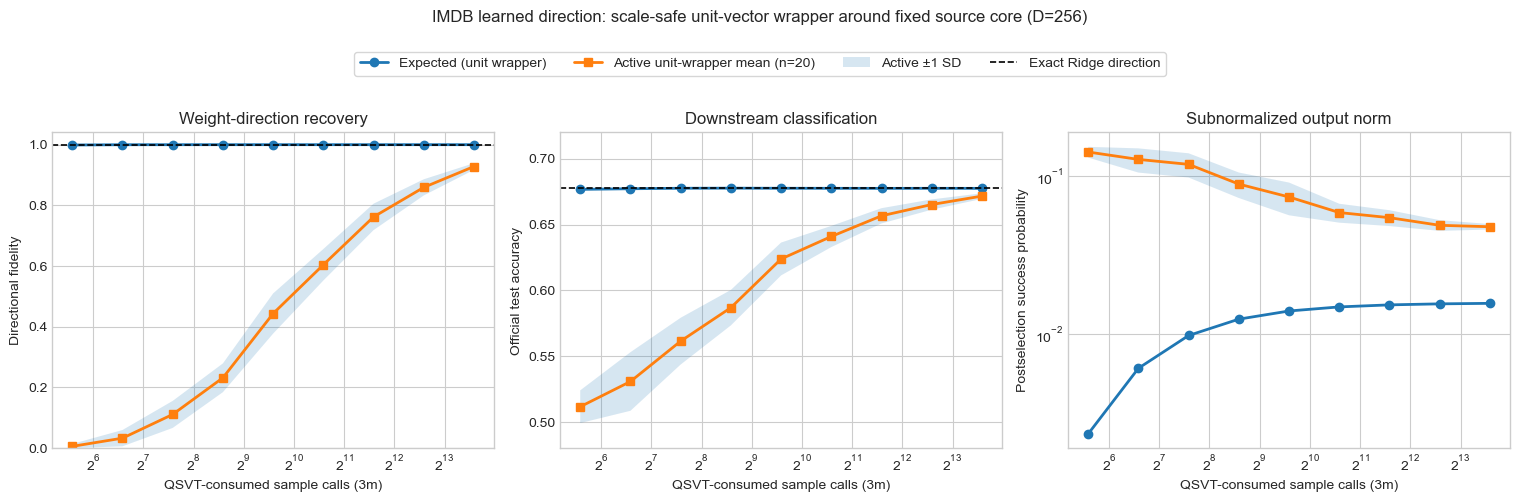

图: assets/figures/imdb_general_vector_qos_sweep.png


In [11]:
qos_figure = FIGURE_DIR / "imdb_general_vector_qos_sweep.png"

expected_plot = qos_summary_df[
    qos_summary_df["method"] == "expected_channel_unit_wrapper"
].sort_values("qsvt_consumed_samples")
active_plot = qos_summary_df[
    qos_summary_df["method"] == "active_sampled_unit_wrapper"
].sort_values("qsvt_consumed_samples")

fig, axes = plt.subplots(1, 3, figsize=(15.3, 4.4))


def plot_metric(ax, mean_column, std_column, ylabel, baseline=None, log_y=False):
    x_expected = expected_plot["qsvt_consumed_samples"].to_numpy()
    x_active = active_plot["qsvt_consumed_samples"].to_numpy()
    expected_mean = expected_plot[mean_column].to_numpy()
    active_mean = active_plot[mean_column].to_numpy()
    active_std = active_plot[std_column].to_numpy()

    ax.plot(
        x_expected,
        expected_mean,
        marker="o",
        linewidth=2,
        label="Expected (unit wrapper)",
    )
    ax.plot(
        x_active,
        active_mean,
        marker="s",
        linewidth=2,
        label=f"Active unit-wrapper mean (n={ACTIVE_REPEATS})",
    )
    ax.fill_between(
        x_active,
        np.maximum(active_mean - active_std, 0),
        active_mean + active_std,
        alpha=0.18,
        label="Active ±1 SD",
    )
    if baseline is not None:
        ax.axhline(
            baseline,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Exact Ridge direction",
        )
    ax.set_xscale("log", base=2)
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("QSVT-consumed sample calls (3m)")
    ax.set_ylabel(ylabel)


plot_metric(
    axes[0],
    "fidelity_mean",
    "fidelity_std",
    "Directional fidelity",
    baseline=1.0,
)
axes[0].set_ylim(0.0, 1.04)
axes[0].set_title("Weight-direction recovery")

plot_metric(
    axes[1],
    "test_accuracy_mean",
    "test_accuracy_std",
    "Official test accuracy",
    baseline=ridge_selected_accuracy,
)
axes[1].set_ylim(0.48, max(0.72, ridge_selected_accuracy + 0.03))
axes[1].set_title("Downstream classification")

plot_metric(
    axes[2],
    "success_probability_mean",
    "success_probability_std",
    "Postselection success probability",
    log_y=True,
)
axes[2].set_title("Subnormalized output norm")

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.05),
)
fig.suptitle(
    "IMDB learned direction: scale-safe unit-vector wrapper around fixed source core (D=256)",
    y=1.13,
    fontsize=12,
)
fig.tight_layout()
fig.savefig(qos_figure, dpi=180, bbox_inches="tight")
plt.show()
print("图:", qos_figure.relative_to(STAGE_ROOT))

## 5. 理论逻辑量子比特公式：$s$ 同时约束行与列

原仓库 `real_datasets/imdb_svm.py` 使用

$$
Q_{\mathrm{logical}}
=2\left\lceil\log_2(N+2D)\right\rceil
+\left\lceil\log_2(s+1)\right\rceil
+4.
$$

论文 [Appendix F.2](https://arxiv.org/pdf/2604.07639#page=124) 的 binary classification 定义明确写道：$s$ 是 $X$ **每行或每列的最大非零数**。固定提交的 [`real_datasets/imdb_svm.py`](https://github.com/haimengzhao/quantum-oracle-sketching/blob/10c092cefcfdff9951bf5729bd2ffb4c25fe2254/real_datasets/imdb_svm.py) 也计算

$$
s_{\mathrm{row}}=\max_i\operatorname{nnz}(X_{i,:}),\qquad
s_{\mathrm{col}}=\max_j\operatorname{nnz}(X_{:,j}),\qquad
s=\max(s_{\mathrm{row}},s_{\mathrm{col}}).
$$

因此这里继续使用 $\max(s_{\mathrm{row}},s_{\mathrm{col}})$，不是只用 row sparsity。CSV 同时保留 `max_row_sparsity_train`、`max_col_sparsity_train` 和最终 `sparsity_formula_input`，便于审计。Hashing 后常见词碰撞会让列非零数很大，这也是为什么必须把两者分开报告。

本 notebook 只代入**训练集**统计量：

- $N=25{,}000$；
- $D$ 为 HashingVectorizer 维度；
- test 完全不参与公式输入。

这一列不包含纠错开销、路由、QRAM、数据装载电路、物理门数、编译增宽或成功概率放大。它只能叫“理论逻辑量子比特公式值”，不能叫实际量子比特占用。

In [12]:
best_classical = classification_df.loc[
    classification_df["official_test_accuracy"].idxmax()
]
max_budget = max(UNIT_SAMPLE_BUDGETS)
expected_max = expected_plot[
    expected_plot["unit_samples_per_group"] == max_budget
].iloc[0]
active_max = active_plot[
    active_plot["unit_samples_per_group"] == max_budget
].iloc[0]
selected_classical = classification_df[
    classification_df["dimension"] == QOS_DIMENSION
].iloc[0]

raw_audit_records = json.loads(
    raw_scale_audit_df.to_json(orient="records", double_precision=15)
)
expected_scale_max_difference = float(
    expected_audit["raw_state_relative_difference_to_c1"].max()
)

notebook_runtime_seconds = time.perf_counter() - NOTEBOOK_T0
summary = {
    "experiment": "IMDB general-vector QOS learned-weight direction reconstruction",
    "provenance": {
        "repository": "haimengzhao/quantum-oracle-sketching",
        "fixed_commit": "10c092cefcfdff9951bf5729bd2ffb4c25fe2254",
        "expected_source": "qos.py::q_state_sketch",
        "active_source": "qos_sampling.py::q_state_sketch",
        "qsvt_source": "qsvt.py",
        "implementation_level": (
            "unchanged fixed-commit NumPy source core wrapped by an intended "
            "scale-safe unit-vector input contract"
        ),
        "quantum_hardware_run": False,
        "compiled_quantum_circuit": False,
    },
    "environment": ENVIRONMENT,
    "dataset_manifest": dataset_manifest,
    "anti_leakage": {
        "official_train_only_for_fit": True,
        "official_test_only_for_evaluation": True,
        "hashing_vectorizer_is_stateless": True,
        "train_unsup_excluded": True,
        "train_test_file_paths_disjoint": True,
    },
    "classification_measured": {
        "dimensions": DIMENSIONS,
        "ridge_alpha": RIDGE_ALPHA,
        "fit_intercept": True,
        "solver": "lsqr",
        "selected_qos_dimension": QOS_DIMENSION,
        "selected_test_accuracy": float(selected_classical["official_test_accuracy"]),
        "selected_train_accuracy": float(selected_classical["official_train_accuracy"]),
        "selected_intercept": intercept,
        "selected_weight_l2_norm": weight_norm,
        "best_dimension": int(best_classical["dimension"]),
        "best_test_accuracy": float(best_classical["official_test_accuracy"]),
    },
    "qos_array_simulation_measured": {
        "main_source_input_contract": MAIN_SOURCE_INPUT_CONTRACT,
        "main_source_vector": "w / ||w||_2",
        "main_source_input_l2_norm": float(np.linalg.norm(qos_source_direction)),
        "main_sweep_directly_inputs_raw_ridge_weight": False,
        "source_core_modified": False,
        "degree_request": QSVT_DEGREE_REQUEST,
        "qsvt_angles_radian": QSVT_ANGLES.tolist(),
        "qsvt_block_calls": QSVT_BLOCK_CALLS,
        "qsvt_validation_max_error": qsvt_validation_max_error,
        "unit_sample_budgets": UNIT_SAMPLE_BUDGETS,
        "active_repeats_per_budget": ACTIVE_REPEATS,
        "random_sign_seed": SEED,
        "unit_wrapper_expected_scale_t": "D / 5 because ||u||_2 = 1",
        "unit_wrapper_active_scale_t": "D / 3 because ||u||_2 = 1",
        "global_orientation": {
            "rule": "multiply q/||q|| by sign(<w/||w||, q/||q||>)",
            "purpose": "remove physically irrelevant global sign before signed classical scoring",
            "uses_classical_target_weight": True,
            "physical_quantum_readout": False,
        },
        "classical_reuse_for_scoring": {
            "multiply_conditional_direction_by_weight_norm": True,
            "retain_ridge_intercept": True,
            "physical_quantum_readout": False,
        },
        "largest_budget": {
            "unit_samples_per_group": max_budget,
            "qsvt_consumed_samples": int(expected_max["qsvt_consumed_samples"]),
            "active_drawn_pairs": int(active_max["actively_drawn_pairs"]),
            "active_unused_samples": int(active_max["unused_samples"]),
            "expected_fidelity": float(expected_max["fidelity_mean"]),
            "expected_test_accuracy": float(expected_max["test_accuracy_mean"]),
            "expected_success_probability": float(
                expected_max["success_probability_mean"]
            ),
            "active_fidelity_mean": float(active_max["fidelity_mean"]),
            "active_fidelity_std": float(active_max["fidelity_std"]),
            "active_test_accuracy_mean": float(active_max["test_accuracy_mean"]),
            "active_test_accuracy_std": float(active_max["test_accuracy_std"]),
            "active_success_probability_mean": float(
                active_max["success_probability_mean"]
            ),
            "active_success_probability_std": float(
                active_max["success_probability_std"]
            ),
        },
    },
    "raw_source_scale_audit": {
        "main_result": False,
        "purpose": (
            "diagnose non-scale-invariance when non-unit vectors are sent directly "
            "to the unchanged active source core"
        ),
        "unit_samples_per_group": RAW_SCALE_AUDIT_UNIT_SAMPLES,
        "same_active_sample_indices_across_scales": True,
        "scale_values": [float(x) for x in RAW_SCALE_VALUES],
        "raw_ridge_weight_scale_c": weight_norm,
        "expected_max_raw_state_relative_difference_to_c1": (
            expected_scale_max_difference
        ),
        "active_unit_input": {
            "success_probability": float(active_unit_audit["success_probability"]),
            "fidelity": float(active_unit_audit["fidelity_to_target"]),
            "test_accuracy": float(
                active_unit_audit["test_accuracy_after_classical_rescale"]
            ),
        },
        "active_raw_ridge_weight_direct_input": {
            "success_probability": float(
                active_raw_weight_audit["success_probability"]
            ),
            "fidelity": float(active_raw_weight_audit["fidelity_to_target"]),
            "test_accuracy": float(
                active_raw_weight_audit["test_accuracy_after_classical_rescale"]
            ),
            "raw_state_relative_difference_to_unit_input": float(
                active_raw_weight_audit[
                    "raw_state_relative_difference_to_c1"
                ]
            ),
            "conditional_direction_distance_to_unit_input": float(
                active_raw_weight_audit[
                    "conditional_direction_distance_to_c1"
                ]
            ),
        },
        "records": raw_audit_records,
    },
    "sample_accounting": {
        "degree_4_groups_generated_active": 4,
        "qsvt_angle_count": 4,
        "qsvt_block_calls": 3,
        "active_groups_consumed": 3,
        "active_fourth_group_consumed": False,
        "active_used_fraction": 0.75,
        "expected_reported_calls_per_unit_m": 3,
        "active_drawn_pairs_per_unit_m": 4,
        "active_consumed_pairs_per_unit_m": 3,
    },
    "theory_formula_only": {
        "formula": "2*ceil(log2(N_train + 2*D)) + ceil(log2(s_train + 1)) + 4",
        "paper_sparsity_definition": (
            "s = max(max nonzeros per row, max nonzeros per column)"
        ),
        "fixed_source_uses_same_definition": True,
        "selected_max_row_sparsity_train": int(
            selected_classical["max_row_sparsity_train"]
        ),
        "selected_max_col_sparsity_train": int(
            selected_classical["max_col_sparsity_train"]
        ),
        "selected_sparsity_formula_input": int(
            selected_classical["sparsity_formula_input"]
        ),
        "physical_qubits": False,
        "hardware_resource_measurement": False,
        "includes_error_correction": False,
    },
    "runtime_seconds": {
        "data_load": data_load_seconds,
        "raw_source_scale_audit": raw_scale_audit_seconds,
        "qos_main_sweep": qos_runtime_seconds,
        "notebook_to_summary": notebook_runtime_seconds,
    },
    "outputs": {
        "dataset_manifest_json": str(manifest_path.relative_to(STAGE_ROOT)),
        "classification_csv": str(classification_csv.relative_to(STAGE_ROOT)),
        "raw_source_scale_audit_csv": str(
            raw_scale_audit_csv.relative_to(STAGE_ROOT)
        ),
        "qos_runs_csv": str(qos_runs_csv.relative_to(STAGE_ROOT)),
        "qos_sweep_csv": str(qos_sweep_csv.relative_to(STAGE_ROOT)),
        "classification_figure": str(classification_figure.relative_to(STAGE_ROOT)),
        "machine_size_accounting_figure": str(
            machine_size_accounting_figure.relative_to(STAGE_ROOT)
        ),
        "qos_figure": str(qos_figure.relative_to(STAGE_ROOT)),
        "qos_schematic": str(schematic_path.relative_to(STAGE_ROOT)),
    },
}

summary_json = RESULTS_DIR / "imdb_general_vector_summary.json"
summary_json.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

display(
    pd.DataFrame(
        [
            {
                "result": "D=256 Ridge held-out accuracy",
                "value": ridge_selected_accuracy,
                "type": "measured classical classification",
            },
            {
                "result": "max-budget expected unit-wrapper fidelity",
                "value": float(expected_max["fidelity_mean"]),
                "type": "measured NumPy QOS array simulation",
            },
            {
                "result": "max-budget active unit-wrapper fidelity mean",
                "value": float(active_max["fidelity_mean"]),
                "type": "measured NumPy QOS array simulation",
            },
            {
                "result": "max-budget active unit-wrapper test accuracy mean",
                "value": float(active_max["test_accuracy_mean"]),
                "type": "array simulation + classical scoring",
            },
            {
                "result": "raw-w direct-input active success probability (audit only)",
                "value": float(active_raw_weight_audit["success_probability"]),
                "type": "raw source scale audit; not a main result",
            },
            {
                "result": "D=256 logical qubits",
                "value": int(selected_classical["theory_logical_qubits_formula"]),
                "type": "theoretical formula only",
            },
        ]
    )
)
print(f"总耗时（写 summary 时）: {notebook_runtime_seconds:.3f} s")
print("summary JSON:", summary_json.relative_to(STAGE_ROOT))

,result,value,type
0,D=256 Ridge held-out accuracy,0.677440,measured classical classification
1,max-budget expected unit-wrapper fidelity,0.999895,measured NumPy QOS array simulation
2,max-budget active unit-wrapper fidelity mean,0.927957,measured NumPy QOS array simulation
3,max-budget active unit-wrapper test accuracy mean,0.671652,array simulation + classical scoring
4,raw-w direct-input active success probability ...,0.001865,raw source scale audit; not a main result
5,D=256 logical qubits,49.000000,theoretical formula only


总耗时（写 summary 时）: 32.714 s
summary JSON: results/imdb_general_vector_summary.json


In [13]:
display(
    Markdown(
        f'''## 6. 本次执行的结论

- **实测经典分类：** `D=256` 的 Ridge 在官方 25,000 条留出 test 上准确率为 **{ridge_selected_accuracy:.3%}**；扩展网格中的最高值是 `D={int(best_classical['dimension'])}` 的 **{float(best_classical['official_test_accuracy']):.3%}**。
- **主实验输入契约：** expected 与 active 都只接收 `w/||w||`，core 内部输入范数为 **{float(np.linalg.norm(qos_source_direction)):.12f}**；原始 Ridge `w` 没有直接进入主 sweep。
- **主 expected 数组仿真：** 最大预算 `m={max_budget}` 得到方向保真度 **{float(expected_max['fidelity_mean']):.6f}**、test accuracy **{float(expected_max['test_accuracy_mean']):.3%}**、成功概率 **{float(expected_max['success_probability_mean']):.6f}**。
- **主 active 数组仿真：** 同一 `m` 下实际抽取 `{4 * max_budget}` 对、仅消费 `{3 * max_budget}` 对；20 次平均方向保真度 **{float(active_max['fidelity_mean']):.6f} ± {float(active_max['fidelity_std']):.6f}**，test accuracy **{float(active_max['test_accuracy_mean']):.3%} ± {float(active_max['test_accuracy_std']):.3%}**，成功概率 **{float(active_max['success_probability_mean']):.6f} ± {float(active_max['success_probability_std']):.6f}**。
- **raw scale audit：** 在相同采样索引下，active core 的单位输入成功概率是 **{float(active_unit_audit['success_probability']):.6f}**，而把原始 Ridge `w` 直接输入时为 **{float(active_raw_weight_audit['success_probability']):.6f}**；条件方向相对单位输入距离为 **{float(active_raw_weight_audit['conditional_direction_distance_to_c1']):.6f}**。这组数字只诊断 double-norm 尺度陷阱，不属于主结果。
- **稀疏度定义：** 论文与固定源码都令 `s=max(max-row-nnz, max-col-nnz)`；`D=256` 时 row、col、最终 `s` 分别为 **{int(selected_classical['max_row_sparsity_train'])}**、**{int(selected_classical['max_col_sparsity_train'])}**、**{int(selected_classical['sparsity_formula_input'])}**。
- **machine-size 图边界：** 新增图的三条曲线共享同一 measured Ridge accuracy，只替换横轴记账；QOS 横轴是理论逻辑量子比特公式，不是硬件测量或独立 QOS accuracy。
- **读出边界：** 朝向校准、乘回 `||w||`、保留 intercept、以及 `X_test @ w_reconstructed` 都复用了经典信息，只用于验证方向，不构成物理量子读出。

主/审计 CSV、数据 manifest、JSON 摘要和 PNG 图均已写入 `results/` 与 `assets/figures/`。'''
    )
)

## 6. 本次执行的结论

- **实测经典分类：** `D=256` 的 Ridge 在官方 25,000 条留出 test 上准确率为 **67.744%**；扩展网格中的最高值是 `D=16384` 的 **85.196%**。
- **主实验输入契约：** expected 与 active 都只接收 `w/||w||`，core 内部输入范数为 **1.000000000000**；原始 Ridge `w` 没有直接进入主 sweep。
- **主 expected 数组仿真：** 最大预算 `m=4096` 得到方向保真度 **0.999895**、test accuracy **67.752%**、成功概率 **0.015660**。
- **主 active 数组仿真：** 同一 `m` 下实际抽取 `16384` 对、仅消费 `12288` 对；20 次平均方向保真度 **0.927957 ± 0.010983**，test accuracy **67.165% ± 0.213%**，成功概率 **0.047694 ± 0.001899**。
- **raw scale audit：** 在相同采样索引下，active core 的单位输入成功概率是 **0.057575**，而把原始 Ridge `w` 直接输入时为 **0.001865**；条件方向相对单位输入距离为 **0.060410**。这组数字只诊断 double-norm 尺度陷阱，不属于主结果。
- **稀疏度定义：** 论文与固定源码都令 `s=max(max-row-nnz, max-col-nnz)`；`D=256` 时 row、col、最终 `s` 分别为 **256**、**19667**、**19667**。
- **machine-size 图边界：** 新增图的三条曲线共享同一 measured Ridge accuracy，只替换横轴记账；QOS 横轴是理论逻辑量子比特公式，不是硬件测量或独立 QOS accuracy。
- **读出边界：** 朝向校准、乘回 `||w||`、保留 intercept、以及 `X_test @ w_reconstructed` 都复用了经典信息，只用于验证方向，不构成物理量子读出。

主/审计 CSV、数据 manifest、JSON 摘要和 PNG 图均已写入 `results/` 与 `assets/figures/`。